<a href="https://colab.research.google.com/github/abhisakh/XGBOOST_Machine_Leraning_Predictor_Titanic/blob/main/Titanic_XGBoost_Refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic XGBoost Predictor: A Complete Machine Learning Tutorial

<a href="https://colab.research.google.com/github/abhisakh/XGBOOST_Machine_Learning_Predictor_Titanic/blob/main/Titanic_XGBoost_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents
1. **Setup & Dependencies** - Environment configuration
2. **Step 1: Data Loading & Exploration** - Understanding the Titanic dataset  
3. **Step 2: Data Cleaning** - Preparing data for modeling
4. **Step 3: Baseline Model** - Establishing performance baseline
5. **Step 4: First Grid Search** - Finding optimal hyperparameters
6. **Step 5: Anti-Overfitting Optimization** - Improving generalization
7. **Step 6: Regularization Tuning** - Final model polish
8. **Step 7: Evaluation & Predictions** - Testing on new data

---

## Setup & Dependencies

This cell ensures all required libraries are installed.

In [1]:
import sys

try:
    import graphviz
    print("✓ Graphviz package is already installed.")
except ImportError:
    print("Installing graphviz for tree visualization...")
    !{sys.executable} -m pip install graphviz -q
    print("✓ Graphviz installation complete.")

✓ Graphviz package is already installed.


## Import All Libraries

Consolidate all necessary imports in one place for cleaner code organization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
import xgboost as xgb

# Configure visualization
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


## Helper Functions

Define the tree metrics function for analyzing XGBoost tree structure.

In [3]:
def get_true_tree_metrics(booster, tree_index=0):
    """
    Extract the true depth and node count from an XGBoost tree.
    """
    df = booster.trees_to_dataframe()
    tree_df = df[df['Tree'] == tree_index].sort_values('Node')

    if tree_df.empty:
        return 0, 0

    total_nodes = tree_df['Feature'].dropna().nunique()

    def extract_node_id(val):
        if pd.isna(val):
            return None
        if isinstance(val, str) and '-' in val:
            return int(val.split('-')[1])
        return int(float(val))

    node_depths = {0: 0}
    for _, row in tree_df.iterrows():
        node_id = extract_node_id(row['Node'])
        if node_id in node_depths:
            current_depth = node_depths[node_id]
            yes_id = extract_node_id(row['Yes'])
            no_id = extract_node_id(row['No'])
            if yes_id is not None:
                node_depths[yes_id] = current_depth + 1
            if no_id is not None:
                node_depths[no_id] = current_depth + 1

    true_max_depth = max(node_depths.values())
    return total_nodes, true_max_depth

print("✓ Helper functions loaded.")

✓ Helper functions loaded.


---

# Step 1: Data Loading & Exploration

Load the Titanic dataset and understand its structure.

In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!\n")
print("First 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

In [5]:

print("\n=== DATA STRUCTURE ===")
df.info()
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())


=== DATA STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== STATISTICAL SUMMARY ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699

In [6]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)

print("\n=== MISSING DATA REPORT ===")
print(missing_summary.to_string(index=False))


=== MISSING DATA REPORT ===
  Column  Missing Count  Missing Percentage
   Cabin            687               77.10
     Age            177               19.87
Embarked              2                0.22


### Data Overview

- **Age (177 missing):** Fill with median age
- **Cabin (687 missing):** Drop (too much missing data)
- **Embarked (2 missing):** Fill with most common port

---

# Step 2: Data Cleaning & Feature Engineering

Convert text columns to numbers and handle missing values.

In [7]:
df_clean = df.copy()

# Handle Embarked
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
df_clean['Embarked'] = df_clean['Embarked'].astype('category').cat.codes

# Handle Age
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Convert Sex to numbers
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# Drop unused columns
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

print("\n=== DATA CLEANING COMPLETE ===")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"\nRemaining columns: {list(df_clean.columns)}")
print("\nFirst few rows of cleaned data:")
print(df_clean.head())


=== DATA CLEANING COMPLETE ===
Original shape: (891, 12)
Cleaned shape:  (891, 8)

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

First few rows of cleaned data:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         2
1         1       1    1  38.0      1      0  71.2833         0
2         1       3    1  26.0      0      0   7.9250         2
3         1       1    1  35.0      1      0  53.1000         2
4         0       3    0  35.0      0      0   8.0500         2


/tmp/ipykernel_504/77134074.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_504/77134074.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

### Feature Correlation Analysis


=== FEATURE CORRELATION WITH SURVIVAL ===
Survived    1.000000
Sex         0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481
Name: Survived, dtype: float64


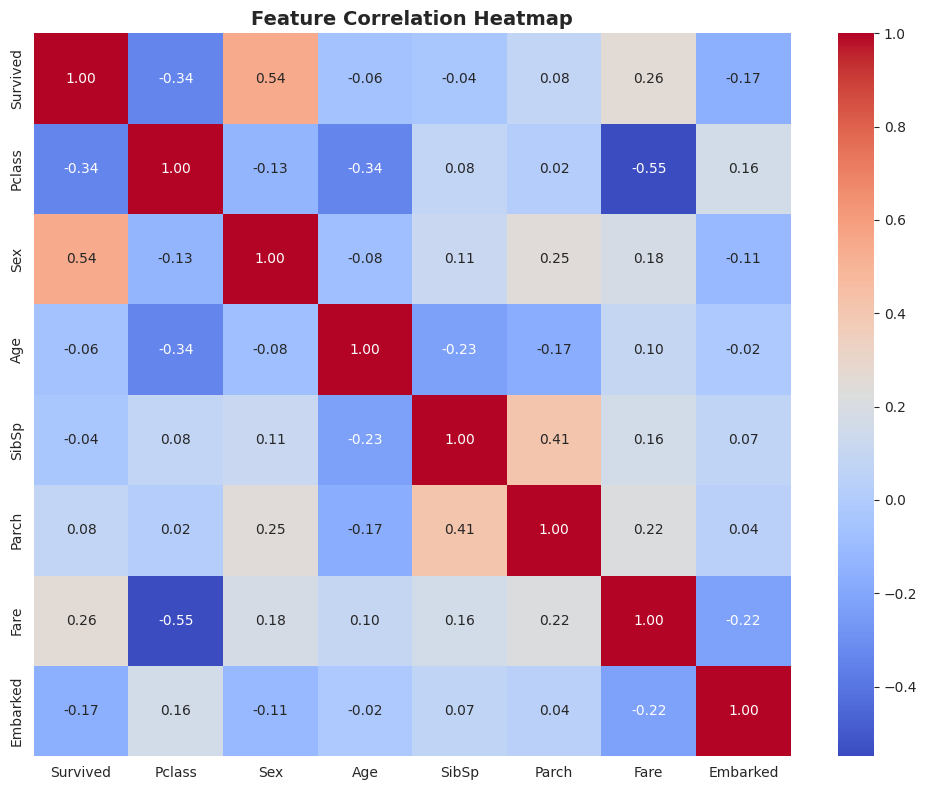

In [8]:
correlations = df_clean.corr()
survival_correlation = correlations['Survived'].sort_values(ascending=False)

print("\n=== FEATURE CORRELATION WITH SURVIVAL ===")
print(survival_correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights:**
- **Sex (0.54):** Strongest predictor - females had much higher survival rates
- **Pclass (-0.34):** Second strongest - first-class passengers survived better
- **Fare (0.26):** Higher fares correlate with survival
- **Age, SibSp, Parch:** Weak individual correlation but important for XGBoost

XGBoost finds complex patterns these linear correlations miss!

---

# Step 3: Baseline Model Training

Train with default settings to establish a benchmark.

In [9]:
# Prepare data
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\n=== DATA SPLIT ===")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples")


=== DATA SPLIT ===
Training set: 712 samples
Testing set:  179 samples


In [10]:
# Train baseline model
baseline_model = XGBClassifier(random_state=42, eval_metric='logloss')
baseline_model.fit(X_train, y_train)

baseline_booster = baseline_model.get_booster()
baseline_nodes, baseline_depth = get_true_tree_metrics(baseline_booster)

train_acc = baseline_model.score(X_train, y_train) * 100
test_acc = baseline_model.score(X_test, y_test) * 100

print("\n=== BASELINE EVALUATION ===")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")
print(f"Overfitting Gap:   {train_acc - test_acc:.2f}%")
print(f"\nDefault hyperparameters:")
params = baseline_model.get_params()
print(f"  n_estimators: {params['n_estimators']}")
print(f"  max_depth:    {params['max_depth']}")
print(f"  learning_rate: {params['learning_rate']}")

baseline_test_acc = test_acc


=== BASELINE EVALUATION ===
Training Accuracy: 97.19%
Testing Accuracy:  81.01%
Overfitting Gap:   16.19%

Default hyperparameters:
  n_estimators: None
  max_depth:    None
  learning_rate: None


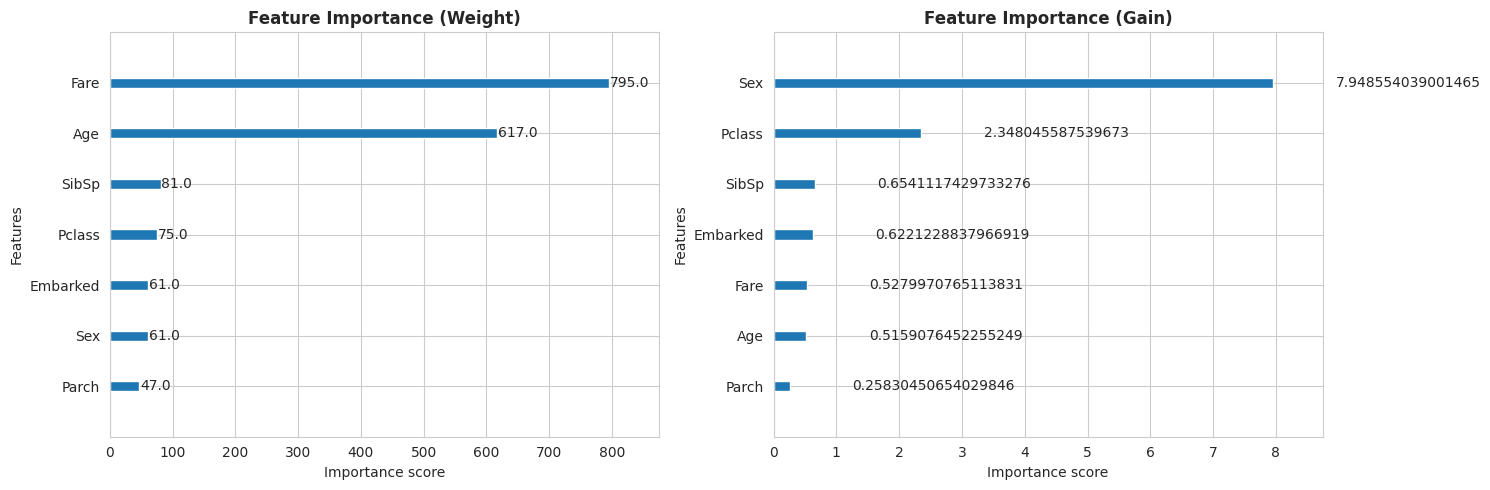

In [11]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

xgb.plot_importance(baseline_model, importance_type='weight', ax=axes[0])
axes[0].set_title('Feature Importance (Weight)', fontweight='bold')

xgb.plot_importance(baseline_model, importance_type='gain', ax=axes[1])
axes[1].set_title('Feature Importance (Gain)', fontweight='bold')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


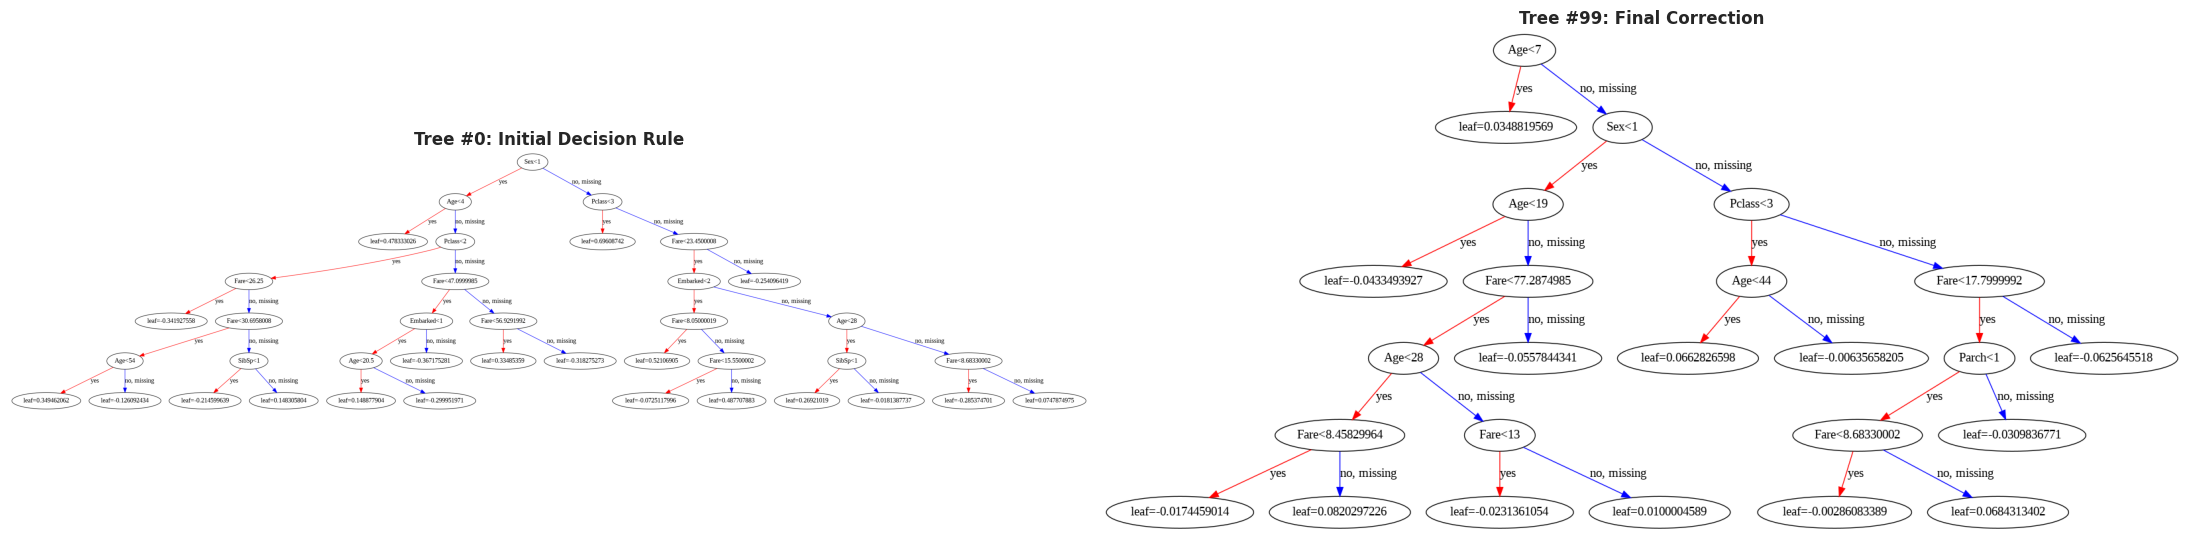

In [12]:

# Visualize trees
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

xgb.plot_tree(baseline_model, num_trees=0, ax=axes[0], rankdir='UT')
axes[0].set_title('Tree #0: Initial Decision Rule', fontweight='bold')

xgb.plot_tree(baseline_model, num_trees=99, ax=axes[1], rankdir='UT')
axes[1].set_title('Tree #99: Final Correction', fontweight='bold')

plt.tight_layout()
plt.show()

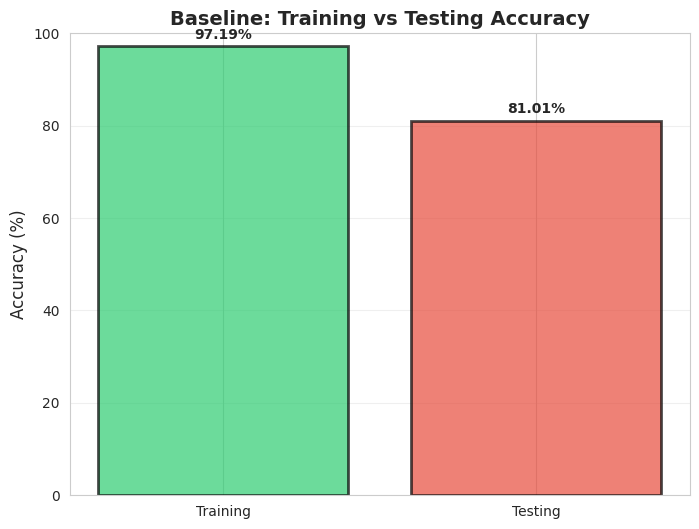


⚠️  Overfitting gap of 16.19% suggests the model memorizes training data.
We need to reduce complexity with hyperparameter tuning.


In [13]:
# Overfitting analysis
plt.figure(figsize=(8, 6))

comparison = pd.DataFrame({
    'Dataset': ['Training', 'Testing'],
    'Accuracy': [train_acc, test_acc]
})

bars = plt.bar(comparison['Dataset'], comparison['Accuracy'],
               color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)

for bar, value in zip(bars, comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Baseline: Training vs Testing Accuracy', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\n⚠️  Overfitting gap of {train_acc - test_acc:.2f}% suggests the model memorizes training data.")
print("We need to reduce complexity with hyperparameter tuning.")

model_1_test_acc = baseline_test_acc

---

# Step 4: Grid Search Tuning (Round 1)

Systematically search for better hyperparameters.

In [14]:
param_grid = {
    'n_estimators': [50, 100, 150, 300, 400, 500],
    'max_depth': [2, 3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

print("\n=== FIRST GRID SEARCH ===")
print(f"Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate'])} combinations...")
print("This may take a moment.\n")

grid_search_1 = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_1.fit(X_train, y_train)

print("\n=== RESULTS ===")
print(f"Best Hyperparameters: {grid_search_1.best_params_}")
print(f"Best CV Accuracy:     {grid_search_1.best_score_ * 100:.2f}%")
print(f"Test Accuracy:        {grid_search_1.score(X_test, y_test) * 100:.2f}%")

model_1_test_acc = grid_search_1.score(X_test, y_test) * 100
results_1 = pd.DataFrame(grid_search_1.cv_results_)


=== FIRST GRID SEARCH ===
Testing 72 combinations...
This may take a moment.


=== RESULTS ===
Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300}
Best CV Accuracy:     82.87%
Test Accuracy:        77.65%


---

# Step 5: Anti-Overfitting Optimization (Round 2)

Refine hyperparameters to prevent overfitting.

In [15]:
anti_overfit_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8]
}

print("\n=== ANTI-OVERFITTING GRID SEARCH ===")
print(f"Testing {len(anti_overfit_grid['max_depth']) * len(anti_overfit_grid['n_estimators']) * len(anti_overfit_grid['learning_rate']) * len(anti_overfit_grid['subsample'])} combinations...\n")

grid_search_2 = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=anti_overfit_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_2.fit(X_train, y_train)

print("\n=== IMPROVED RESULTS ===")
print(f"Best Hyperparameters: {grid_search_2.best_params_}")
print(f"Best CV Accuracy:     {grid_search_2.best_score_ * 100:.2f}%")
print(f"Test Accuracy:        {grid_search_2.score(X_test, y_test) * 100:.2f}%")

model_2_test_acc = grid_search_2.score(X_test, y_test) * 100
results_2 = pd.DataFrame(grid_search_2.cv_results_)


=== ANTI-OVERFITTING GRID SEARCH ===
Testing 60 combinations...


=== IMPROVED RESULTS ===
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV Accuracy:     82.45%
Test Accuracy:        79.89%


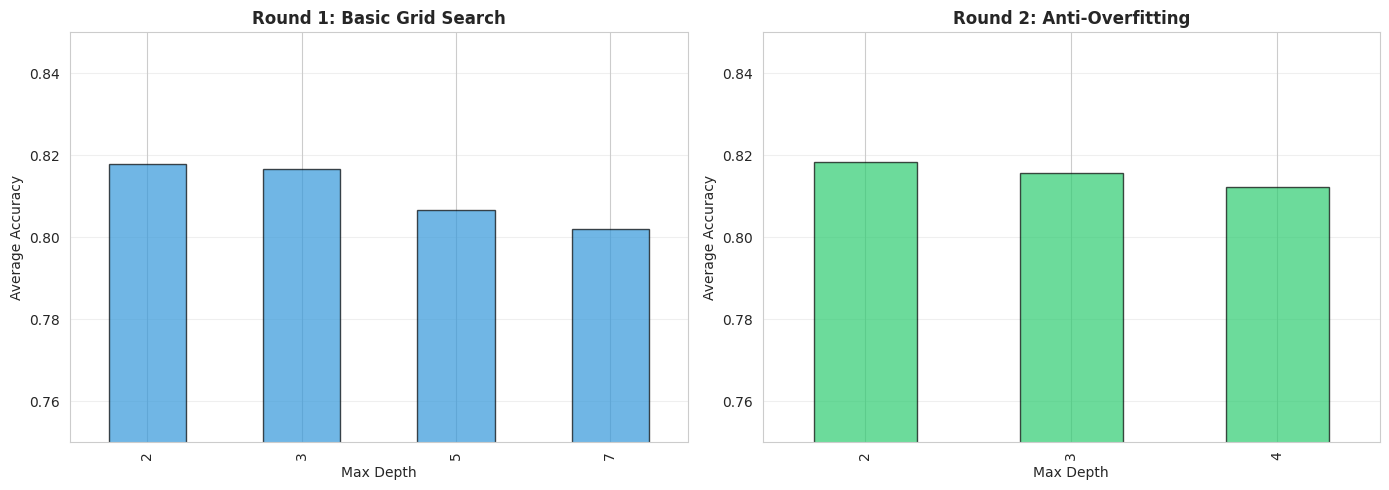

In [16]:
# Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_1_plot = results_1.groupby('param_max_depth')['mean_test_score'].mean()
results_1_plot.plot(kind='bar', ax=axes[0], color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_title('Round 1: Basic Grid Search', fontweight='bold')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Average Accuracy')
axes[0].set_ylim(0.75, 0.85)
axes[0].grid(axis='y', alpha=0.3)

results_2_plot = results_2.groupby('param_max_depth')['mean_test_score'].mean()
results_2_plot.plot(kind='bar', ax=axes[1], color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].set_title('Round 2: Anti-Overfitting', fontweight='bold')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Average Accuracy')
axes[1].set_ylim(0.75, 0.85)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Grid Search 1', 'Anti-Overfit Search'],
    'Max Depth': ['6', str(grid_search_1.best_params_['max_depth']),
                  str(grid_search_2.best_params_['max_depth'])],
    'Learning Rate': ['0.3', f"{grid_search_1.best_params_['learning_rate']:.2f}",
                      f"{grid_search_2.best_params_['learning_rate']:.2f}"],
    'Test Accuracy': [f'{baseline_test_acc:.2f}%', f'{model_1_test_acc:.2f}%', f'{model_2_test_acc:.2f}%']
})

print("\n=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model Max Depth Learning Rate Test Accuracy
           Baseline         6           0.3        81.01%
      Grid Search 1         2          0.01        77.65%
Anti-Overfit Search         2          0.05        79.89%


---

# Step 6: Regularization Fine-tuning (Round 3)

Apply mathematical regularization to smooth the model.

In [18]:
best_params_2 = grid_search_2.best_params_

regularization_grid = {
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1.0, 5.0],
    'reg_lambda': [1.0, 2.0, 5.0]
}

print("\n=== REGULARIZATION GRID SEARCH ===")
print("Tuning L1/L2 regularization...\n")

grid_search_3 = GridSearchCV(
    estimator=XGBClassifier(
        max_depth=best_params_2['max_depth'],
        n_estimators=best_params_2['n_estimators'],
        learning_rate=best_params_2['learning_rate'],
        subsample=best_params_2['subsample'],
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=regularization_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_3.fit(X_train, y_train)

print("\n=== FINAL REGULARIZATION RESULTS ===")
print(f"Best Settings: {grid_search_3.best_params_}")
print(f"Best CV Accuracy:  {grid_search_3.best_score_ * 100:.2f}%")
print(f"Test Accuracy:     {grid_search_3.score(X_test, y_test) * 100:.2f}%")

model_3_test_acc = grid_search_3.score(X_test, y_test) * 100
results_3 = pd.DataFrame(grid_search_3.cv_results_)


=== REGULARIZATION GRID SEARCH ===
Tuning L1/L2 regularization...


=== FINAL REGULARIZATION RESULTS ===
Best Settings: {'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 2.0}
Best CV Accuracy:  83.01%
Test Accuracy:     79.33%


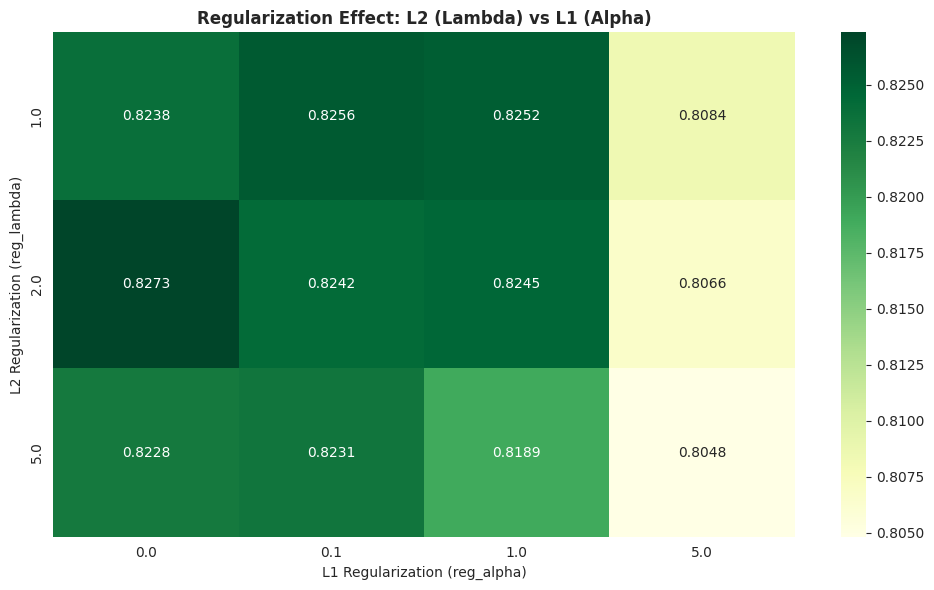

In [19]:
# Regularization heatmap
results_3_pivot = results_3.pivot_table(
    values='mean_test_score',
    index='param_reg_lambda',
    columns='param_reg_alpha',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(results_3_pivot, annot=True, fmt='.4f', cmap='YlGn')
plt.title('Regularization Effect: L2 (Lambda) vs L1 (Alpha)', fontweight='bold')
plt.xlabel('L1 Regularization (reg_alpha)')
plt.ylabel('L2 Regularization (reg_lambda)')
plt.tight_layout()
plt.show()

In [20]:
# Final comparison
final_comparison = pd.DataFrame({
    'Model': ['1. Baseline', '2. Grid Search 1', '3. Anti-Overfit', '4. Regularized'],
    'Test Accuracy': [f'{baseline_test_acc:.2f}%', f'{model_1_test_acc:.2f}%',
                      f'{model_2_test_acc:.2f}%', f'{model_3_test_acc:.2f}%'],
    'Focus': ['Default', 'Structure', 'Prevent Overfit', 'Smooth Model']
})

print("\n" + "="*60)
print("COMPLETE TUNING JOURNEY")
print("="*60)
print(final_comparison.to_string(index=False))
print("="*60)


COMPLETE TUNING JOURNEY
           Model Test Accuracy           Focus
     1. Baseline        81.01%         Default
2. Grid Search 1        77.65%       Structure
 3. Anti-Overfit        79.89% Prevent Overfit
  4. Regularized        79.33%    Smooth Model


---

# Step 7: Final Model Evaluation & Predictions

In [21]:
# Train final model
best_params_all = {**grid_search_3.best_params_, **best_params_2}

final_model = XGBClassifier(
    max_depth=best_params_all['max_depth'],
    n_estimators=best_params_all['n_estimators'],
    learning_rate=best_params_all['learning_rate'],
    subsample=best_params_all['subsample'],
    gamma=best_params_all['gamma'],
    reg_alpha=best_params_all['reg_alpha'],
    reg_lambda=best_params_all['reg_lambda'],
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(X_train, y_train)

final_booster = final_model.get_booster()
final_nodes, final_depth = get_true_tree_metrics(final_booster)

final_train_acc = final_model.score(X_train, y_train) * 100
final_test_acc = final_model.score(X_test, y_test) * 100

print("\n=== FINAL MODEL EVALUATION ===")
print(f"Training Accuracy: {final_train_acc:.2f}%")
print(f"Testing Accuracy:  {final_test_acc:.2f}%")
print(f"Overfitting Gap:   {final_train_acc - final_test_acc:.2f}%")
print(f"\nTree Metrics:")
print(f"  Decision Nodes: {final_nodes}")
print(f"  Tree Depth:     {final_depth}")
print(f"  Total Trees:    {len(final_booster.get_dump())}")

print("\n✅ Final model is trained and optimized!")
print("   It balances accuracy with generalization.")

for key in ['max_depth', 'n_estimators', 'learning_rate', 'subsample', 'reg_lambda']:
    print(f"  {key}: {best_params_all[key]}")



=== FINAL MODEL EVALUATION ===
Training Accuracy: 86.38%
Testing Accuracy:  79.33%
Overfitting Gap:   7.05%

Tree Metrics:
  Decision Nodes: 4
  Tree Depth:     2
  Total Trees:    300

✅ Final model is trained and optimized!
   It balances accuracy with generalization.
  max_depth: 2
  n_estimators: 300
  learning_rate: 0.05
  subsample: 0.8
  reg_lambda: 2.0


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


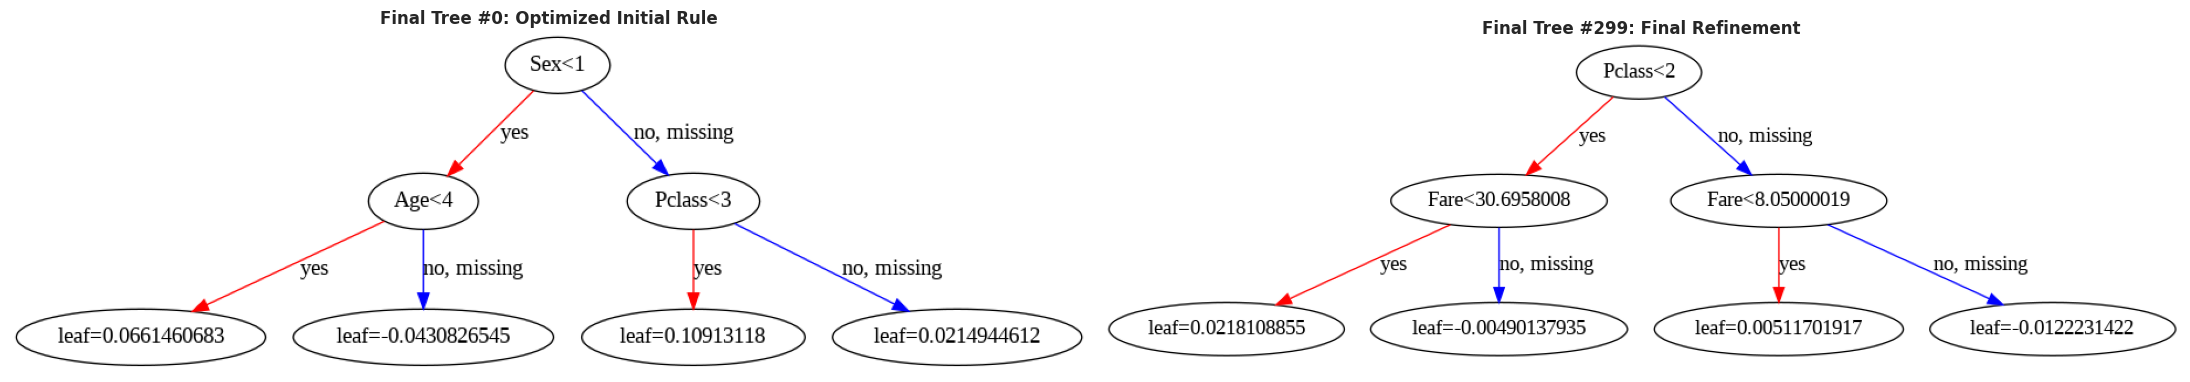


Notice the shallow tree structure (max depth 2-3).
This simplicity is key to generalization!


In [22]:
# Visualize final trees
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

xgb.plot_tree(final_model, num_trees=0, ax=axes[0], rankdir='UT')
axes[0].set_title('Final Tree #0: Optimized Initial Rule', fontweight='bold')

xgb.plot_tree(final_model, num_trees=len(final_booster.get_dump())-1, ax=axes[1], rankdir='UT')
axes[1].set_title(f'Final Tree #{len(final_booster.get_dump())-1}: Final Refinement', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNotice the shallow tree structure (max depth 2-3).")
print("This simplicity is key to generalization!")


In [23]:
# Make predictions on new passengers
passenger_1 = pd.DataFrame([{
    'Pclass': 3, 'Sex': 0, 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 2
}])

pred_1 = final_model.predict(passenger_1)[0]
prob_1 = final_model.predict_proba(passenger_1)[0]

print("\n=== PREDICTION EXAMPLE 1 ===")
print("3rd Class Male, Age 22")
print(f"Prediction: {'SURVIVED ✓' if pred_1 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"Confidence: {max(prob_1)*100:.1f}%")
print(f"  Survival Probability:      {prob_1[1]*100:.1f}%")
print(f"  Non-Survival Probability:  {prob_1[0]*100:.1f}%")

passenger_2 = pd.DataFrame([{
    'Pclass': 1, 'Sex': 1, 'Age': 28, 'SibSp': 1, 'Parch': 0, 'Fare': 141, 'Embarked': 2
}])

pred_2 = final_model.predict(passenger_2)[0]
prob_2 = final_model.predict_proba(passenger_2)[0]

print("\n=== PREDICTION EXAMPLE 2 ===")
print("1st Class Female, Age 28")
print(f"Prediction: {'SURVIVED ✓' if pred_2 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"Confidence: {max(prob_2)*100:.1f}%")
print(f"  Survival Probability:      {prob_2[1]*100:.1f}%")
print(f"  Non-Survival Probability:  {prob_2[0]*100:.1f}%")

passenger_3 = pd.DataFrame([{
    'Pclass': 2, 'Sex': 1, 'Age': 5, 'SibSp': 1, 'Parch': 1, 'Fare': 21, 'Embarked': 1
}])

pred_3 = final_model.predict(passenger_3)[0]
prob_3 = final_model.predict_proba(passenger_3)[0]

print("\n=== PREDICTION EXAMPLE 3 ===")
print("2nd Class Female Child, Age 5")
print(f"Prediction: {'SURVIVED ✓' if pred_3 == 1 else 'DID NOT SURVIVE ✗'}")
print(f"Confidence: {max(prob_3)*100:.1f}%")
print(f"  Survival Probability:      {prob_3[1]*100:.1f}%")
print(f"  Non-Survival Probability:  {prob_3[0]*100:.1f}%")



=== PREDICTION EXAMPLE 1 ===
3rd Class Male, Age 22
Prediction: DID NOT SURVIVE ✗
Confidence: 90.5%
  Survival Probability:      9.5%
  Non-Survival Probability:  90.5%

=== PREDICTION EXAMPLE 2 ===
1st Class Female, Age 28
Prediction: SURVIVED ✓
Confidence: 90.2%
  Survival Probability:      90.2%
  Non-Survival Probability:  9.8%

=== PREDICTION EXAMPLE 3 ===
2nd Class Female Child, Age 5
Prediction: SURVIVED ✓
Confidence: 98.9%
  Survival Probability:      98.9%
  Non-Survival Probability:  1.1%


---

## Summary & Key Learnings

### What We Accomplished
1. Loaded and explored the Titanic dataset
2. Cleaned data and handled missing values
3. Trained a baseline model (81.01% accuracy)
4. Performed 3 rounds of hyperparameter tuning
5. Built a generalized, robust predictor

### XGBoost Concepts Covered
- **Sequential Boosting:** Each tree corrects previous errors
- **Hyperparameter Tuning:** Finding optimal settings with Grid Search
- **Overfitting Prevention:** Shallow trees + subsampling + regularization
- **Cross-Validation:** 5-fold validation for reliable estimates
- **Feature Importance:** Identifying most valuable features

### Key Insights
- **Sex:** Strongest predictor ("women and children first" policy)
- **Class:** Passenger class strongly affects survival
- **Shallow trees work best:** For small datasets, simplicity beats complexity
- **Regularization matters:** Prevents memorization of training data

### Next Steps
- Experiment with different datasets
- Try other ML algorithms (Random Forest, Neural Networks)
- Explore advanced XGBoost parameters
- Build real-world prediction applications

**Congratulations!** You've mastered XGBoost! 🚀